# Setup

## Import modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import warnings

# import local utils
import utils.preprocessing as preprocessing
import utils.dataloader as dataloader
from cycler import cycler

plt.style.use(["science", "ieee", "vibrant"])
# Remove the fourth color as it is very similiar to the third for vibrant palette
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors.pop(3)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)

#plt.style.use(["science", "ieee", "muted"])
warnings.filterwarnings('ignore')

## Set globals

In [3]:
PLOT_DURATION_LIMIT = 60
RAW_DATA_DIR = "./raw"

## Data loading and preprocessing

In [4]:
experiments = dataloader.load_experiment_data(RAW_DATA_DIR)#, ["control_plane"])

print(f"Loaded experiments: {list(experiments.keys())}")
print(f"Systems loaded (for Capsule as example): {list(experiments['capsule'].keys())}")

Loaded experiments: ['capsule-proxy', 'capsule', 'vcluster', 'kubezoo', 'kubevirt']
Systems loaded (for Capsule as example): ['control_plane', 'network', 'workload', 'storage']


In [5]:
import matplotlib as mathplotlib
def save_plot(fig, filename):
    # Save without any axis title
    # Remove titles from all axes before saving
    for ax in fig.get_axes():
        ax.set_title('')  # Remove individual subplot titles
    fig.savefig(f'{filename}.png', bbox_inches='tight', dpi=300)
    
    current_backend = mathplotlib.get_backend()
    current_usetex = mathplotlib.rcParams['text.usetex']
    
    # Switch to PGF for high-quality output
    mathplotlib.use("pgf")
    mathplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
    })
    
    fig.savefig(f'{filename}.pgf', bbox_inches='tight')
    
    # Switch back to interactive backend
    mathplotlib.use(current_backend)
    mathplotlib.rcParams.update({"text.usetex": current_usetex})


def plot_for_paper(text_width=3.31314,
                aspect_ratio=6/8,
                dpi=300,
                scale=1.0):
    """Resize the plot to a specific text width and aspect ratio"""
    scale = 1.0
    width = text_width * scale
    height = width * aspect_ratio
    fig, ax =  plt.subplots(figsize=(width, height), dpi=dpi)
    return fig,ax


In [6]:
def plot_scatter(data, ax, title, xlabel, ylabel, filename, scale=1.0):
    """Plot a scatter plot with a regression line and save it in both PNG and PGF formats."""
    #shapes = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']  # Add more shapes if needed
    for label, x, y in data:
        # use symbols with different shapes
        ax.scatter(x, y, label=label, alpha=0.8, s=5,) #marker=shapes[hash(label) % len(shapes)])
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    # Set log scale for y-axis if needed
    ax.set_yscale('log')
    # make closer the legend symbols and the text
    ax.legend(loc='upper left', frameon=True, framealpha=0.9, borderpad=0.5, handletextpad=0.5, handlelength=1.0)
    
    ax.set_xlim(0, PLOT_DURATION_LIMIT)
    # set image scale
    
    fig = ax.get_figure()
    


In [7]:
def plot_latency_over_time(experiments, system, save_plots=True, out_dir="./", single_column_size=True, max_duration=None):
    """Plot regular tenant moving latency average transition across all solutions for comparison"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        "capsule": "Capsule",
        "capsule-proxy": "Capsule-Proxy",
        "kubezoo": "KubeZoo",
        "vcluster": "vCluster",
        "kubevirt": "KubeVirt"
    }
    solution_to_label = {k: solution_to_label[k] for k in solution_to_label if k in solutions}
    
    fig, ax = None, None
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(3.31314*2, aspect_ratio=6/16) # 3.31314 is the width of a single column in the paper
    
    baseline_duration = 20  # Fixed 20 seconds for baseline
    baseline_time_offset = 2 
    stress_time_offset = 0
    
    window_size = 2.0
    window_step = 0.5    
    
    # Get colors from the current style
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    linewidth = 0.75
    stress_test_begin_linewidth = 0.5
    
    if not single_column_size:
        linewidth *= 2
        stress_test_begin_linewidth *= 2
    
    line_styles = ['-', '--', '-.', ':']
    markers = ['','v', 's', 'P', 'D', 'v', '<', '>', 'p', '*', 'h']
    marker_sizes = [0,1, 1, 1, 1, 0.5, 1, 1, 1, 1, 0.5]

    
    print(f"Loading data from all solutions for regular tenant comparison...")
    
    ordered_solution_labels = list(solution_to_label.items())
    
    for i, (solution, label) in enumerate(ordered_solution_labels):
        stress_experiment = experiments[solution][system]['stress_test']
        baseline_experiment = experiments[solution][system]['baseline']
            
        # time_series = stress_experiment.get_time_series(window_size=window_size, window_step=window_step)[0] # Get t1 time series
        # all_times = time_series['window_start'] + window_size / 2  # Use the center of the window for plotting
        # all_values = time_series['avg_latency_ms']
        
        # Calculate rolling average for the entire timeline
        all_times = []
        all_values = []
        

        # Baseline portion (0-10s)
        baseline_portion = baseline_experiment.t1_df[baseline_experiment.t1_df['elapsed_seconds'] <= baseline_duration + baseline_time_offset]
        baseline_portion = baseline_portion[baseline_portion['elapsed_seconds'] >= baseline_time_offset]  # Focus on the last 10 seconds of the baseline
        #translate time
        baseline_portion['elapsed_seconds'] = baseline_portion['elapsed_seconds'] - baseline_time_offset
        # remove outliers for better visualization (keep only values below 100ms)
        #baseline_portion = baseline_portion[baseline_portion['duration_ms'] < 100]  
        time_points = np.arange(0, baseline_duration, window_step)
        for t in time_points:
            window_mask = (baseline_portion['elapsed_seconds'] >= t - window_size/2) & \
                         (baseline_portion['elapsed_seconds'] <= t + window_size/2)
            window_data = baseline_portion[window_mask]
            
            if len(window_data) >= 1:
                all_times.append(t)
                all_values.append(window_data['duration_ms'].mean())
        
        # Stress portion (10s+)
        stress_portion = stress_experiment.t1_df[stress_experiment.t1_df['elapsed_seconds'] >=  stress_time_offset]     
        stress_portion = stress_portion[stress_portion['elapsed_seconds'] <= PLOT_DURATION_LIMIT + stress_time_offset]  # Focus on the first 50 seconds of the stress test
        #translate time
        stress_portion['elapsed_seconds'] = stress_portion['elapsed_seconds'] - stress_time_offset
        print(f"Processing stress portion for {solution} with {len(stress_portion)} data points...")
        if len(stress_portion) > 0:
            max_stress_time = min(stress_portion['elapsed_seconds'].max(), PLOT_DURATION_LIMIT)
            time_points = np.arange(baseline_duration, max_stress_time, window_step)
            # remove outliers for better visualization (keep only values below 100ms)
            #stress_portion = stress_portion[stress_portion['duration_ms'] < 100]
            for t in time_points:
                window_mask = (stress_portion['elapsed_seconds'] >= t - window_size/2) & \
                             (stress_portion['elapsed_seconds'] <= t + window_size/2)
                window_data = stress_portion[window_mask]
                
                if len(window_data) >= 1:
                    all_times.append(t)
                    all_values.append(window_data['duration_ms'].mean())
        
        
        
        
        ax.plot(all_times, all_values, 
                       label=f'{label}', 
                       #linewidth=linewidth,
                       #marker=markers[i],
                       #markersize=marker_sizes[i]*1.5,
                       #markevery=4
        )
                
    
    # Add visual elements
    ax.axvline(x=baseline_duration, color='black', linestyle='--', alpha=1, linewidth=stress_test_begin_linewidth,
                label=None)
            #    label='Stress Test Start')
    
    # Add phase shading
    # ax.axvspan(0, baseline_duration, alpha=0.1, color='green', label='Baseline Phase')
    # ax.axvspan(baseline_duration, PLOT_DURATION_LIMIT, alpha=0.1, color='orange', label='Stress Test Phase')
    
    # Customize the plot
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Moving Average Latency Across Solutions')
    ax.set_xlim(0, max_duration if max_duration else PLOT_DURATION_LIMIT) 
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Set y-axis limits for better visibility
    ax.tick_params(axis='y', which='minor', left=True)
    ax.text(baseline_duration+20, ax.get_ylim()[0]*1.7,
            'High Load (with Noisy Tenant)',
            rotation=0, ha='center', va='bottom', fontsize='small', alpha=1)
    ax.text(baseline_duration-10, ax.get_ylim()[0]*1.7,
        'Low Load',
        rotation=0, ha='center', va='bottom', fontsize='small', alpha=1)

    
    ax.legend(bbox_to_anchor=(0.5, 1.35), loc='upper center',
            fancybox=False, shadow=False, frameon=False,
            handlelength=0.8, handletextpad=0.3,
            borderpad=0.5, columnspacing=1.5,
            ncol=3)
    # Add y spacing for the legend
    #plt.subplots_adjust(bottom=0.25)  # Increase bottom margin for legend
    
    # Format y-axis labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    plt.tight_layout()
    
    if save_plots:
        save_plot(fig, f'{out_dir}/moving_avg_latency')
    plt.show()


In [ ]:
def plot_latency_boxplot(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule\nProxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []
    boxplot_width=0.4

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += boxplot_width
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += boxplot_width
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += boxplot_width
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - boxplot_width) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

    # meanpointprops = dict(marker='D', markeredgecolor='#520808',
    #                   markerfacecolor=colors[3], markersize=3)
    # Create box plot 
    bp = ax.boxplot(box_data, positions=positions, patch_artist=True, 
                    labels=box_labels, showfliers=False,
                    showmeans=False,
                    widths=boxplot_width,
                    #meanprops=meanpointprops,
                    medianprops={'color': 'black', 'linewidth': 0.75},
                    whiskerprops={'linewidth': 0.75, 'color': 'black'},
                    capprops={'linewidth': 0.75, 'color': 'black'})
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bp['boxes'], box_labels):
        rgba_color = mcolors.to_rgba(role_colors[label], alpha=0.6)
        patch.set_facecolor(rgba_color)
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor('black')
        patch.set_linewidth(0.75)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]


    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, 1.26), loc='upper center', 
            frameon=False, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            handlelength=0.8,
            #fontsize='small'
    )
    
    
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)

    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    # # Adjust layout with less space reserved for legend
    # plt.subplots_adjust(top=0.75) 
    
    if save_plots:
        save_plot(fig, f'{out_dir}/latency_comparison')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")

In [9]:
def plot_comparative_latency_distribution_p95(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule-Proxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += 0.3
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += 0.3
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

# Calculate P95 for each dataset instead of passing raw data
    p95_data = []
    
    # Calculate P95s
    for i, data in enumerate(box_data):
        if len(data) > 0:
            p95_data.append(np.percentile(data, 95))
        else:
            p95_data.append(0)

    # Create Bar Plot
    bar_width = 0.25
    
    # Adjust positions for bars (centering them)
    # unique_positions = sorted(list(set(positions))) # logic needs to align with your loop
    # We can reuse your 'positions' list directly for bars
    
    bars = ax.bar(positions, p95_data, width=bar_width, align='center')

    # Color the bars
    for i, bar in enumerate(bars):
        label = box_labels[i]
        bar.set_color(role_colors[label])
        bar.set_alpha(0.8)
        bar.set_edgecolor('black')
        bar.set_linewidth(1)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.05,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=8, rotation=0)

    # Customize the plot
    ax.set_ylabel('P95 Latency (ms)')
    ax.set_title('95th Percentile Latency across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    
    import matplotlib.colors as mcolors
    # Color the boxes
    for patch, label in zip(bars, box_labels):
        patch.set_facecolor(role_colors[label])
        patch.set_alpha(0.6)  # Set transparency for better visibility
        darker_color = mcolors.to_rgb(role_colors[label])
        darker_color = tuple(c * 0.6 for c in darker_color)
        patch.set_edgecolor(darker_color)
        patch.set_linewidth(1)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add role labels as secondary x-axis
    # for i, pos in enumerate(positions):
    #     role = box_labels[i]
    #     ax.text(pos, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03, 
    #         role, ha='center', va='top', fontsize=8)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)
    # Add statistics annotations (median values)
    # y_max = ax.get_ylim()[1]
    # for i, (data, label) in enumerate(zip(box_data, box_labels)):
    #     if len(data) > 0:
    #         median_val = np.median(data)
    #         # Add median value as text above each box
    #         ax.text(positions[i], median_val - (ax.get_ylim()[1] * 0.01), f'{median_val:.0f}ms', 
    #            ha='center', va='bottom', fontsize=9, fontweight='bold',
    #            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=1, edgecolor='none'))
    
    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")
            
            

In [10]:
def plot_comparative_latency_distribution_violin(experiments, system, save_plots=True, out_dir="./", single_column_size=True):
    """Create a comparative box plot showing latency distribution by role for all solutions"""
    
    solutions = list(experiments.keys())
    solution_to_label = {
        'capsule': 'Capsule',
        'capsule-proxy': 'Capsule-Proxy',
        'kubezoo': 'KubeZoo',
        'vcluster': 'vCluster',
        'kubevirt': 'KubeVirt'
    }
    solution_to_label = {s: l for s, l in solution_to_label.items() if s in solutions}
    
    experiments_selected = {}
    # Load data from all solutions
    for solution in solutions:
        try:
            stress_experiment = experiments[solution][system]['stress_test']
            baseline_experiment = experiments[solution][system]['baseline']
            
            
            experiments_selected[solution] = {
                'stress': stress_experiment,
                'baseline': baseline_experiment
            }
        except Exception as e:
            print(f"Error loading data for {solution}: {e}")
            continue

    
    if not experiments_selected:
        print("No data loaded for any solution")
        return
    
    fig, ax = None, None
    # Create the plot
    if single_column_size:
        fig, ax = plot_for_paper()
    else:
        fig, ax = plot_for_paper(text_width=6.6)
    
    # Prepare data for box plot
    box_data = []
    box_labels = []
    
    # Get default color cycle from the current style
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    # Use first two colors from the style for Regular and Malicious
    role_colors = {
        'Baseline': colors[2],    # Third color for baseline
        'Regular': colors[0],     # First color from style
        'Malicious': colors[1]    # Second color from style
    }
    
    positions = []
    pos = 1
    solution_positions = []
    solution_labels = []

    for (solution, label) in solution_to_label.items():
        if solution not in experiments_selected:
            continue
            
        solution_start_pos = pos
        
        baseline_exp = experiments_selected[solution]['baseline']
        
        latencies = baseline_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append('Baseline')
        positions.append(pos)
        pos += 0.3
        
        # Add stress test data for both roles
        stress_exp = experiments_selected[solution]['stress']

        latencies = stress_exp.t1_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Regular")
        positions.append(pos)
        pos += 0.3
        
        latencies = stress_exp.t2_df['duration_ms']
        box_data.append(latencies.values)
        box_labels.append("Malicious")
        positions.append(pos)
        pos += 0.3
        
        # Store solution position (center between the two boxes)
        solution_positions.append((solution_start_pos + pos - 0.3) / 2)
        solution_labels.append(label)
        
        # Add spacing between solutions
        pos += 1

## Create Violin Plot
    parts = ax.violinplot(box_data, positions=positions, 
                          showmeans=True, showmedians=False, showextrema=True,
                          widths=0.3)

    # Color the violins
    for i, pc in enumerate(parts['bodies']):
        label = box_labels[i]
        pc.set_facecolor(role_colors[label])
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)

    # Style the lines (min/max/mean) to be black
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1)

    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution (Violin) across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
        
        
    
    # Customize the plot
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Latency Distribution across Solutions')
    
    # Set custom x-axis labels
    ax.set_xticks(solution_positions)
    ax.set_xticklabels(solution_labels)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=role_colors['Baseline'], alpha=0.7, label='Regular user\n (low load)'),
        Patch(facecolor=role_colors['Regular'], alpha=0.7, label='Regular user\n (high load)'),
        Patch(facecolor=role_colors['Malicious'], alpha=0.7, label='Malicious user\n (high load)')
    ]
    
    # Replace the legend section with:
    # Adjust layout with less space reserved for legend
    plt.subplots_adjust(bottom=0.15)  # Reduce from 0.2 to 0.15

    # And use smaller legend
    ax.legend(handles=legend_elements, bbox_to_anchor=(0.5, -0.12), loc='upper center', 
            frameon=True, fancybox=False, shadow=False,
            handletextpad=0.25, columnspacing=0.6, ncol=3, 
            fontsize='small', handlelength=0.8)
    
    # Reduce x-axis padding
    ax.set_xlim(0.5, max(positions) + 0.5)

    plt.tight_layout()
    plt.minorticks_off()
    # log scale
    ax.set_yscale('log')
    ax.set_ylim(bottom=1)  # Avoid log(0) issues
    # Make the y-axis ticks labels be like 0.1, 1, 10, 100, etc.
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{int(x)}'))
    
    if save_plots:
        save_plot(fig, f'{out_dir}/comparative_latency_distribution')
        #plt.savefig(f'{out_dir}/comparative_latency_distribution.png', dpi=600, bbox_inches='tight')
    
    plt.show()

    # Print summary statistics
    print("\n" + "="*80)
    print("COMPARATIVE LATENCY ANALYSIS")
    print("="*80)
    
    for solution in solutions:
        if solution not in experiments_selected:
            continue
        
        print(f"\n{solution.upper()}:")

        # Print baseline statistics
        baseline_regular = experiments_selected[solution]['baseline'].t1_df
        if len(baseline_regular) > 0:
            latencies = baseline_regular['duration_ms']
            print(f"  Baseline:")
            print(f"    Requests: {len(latencies):,}")
            print(f"    Mean: {latencies.mean():.1f}ms")
            print(f"    Median: {latencies.median():.1f}ms")
            print(f"    P95: {latencies.quantile(0.95):.1f}ms")
            print(f"    P99: {latencies.quantile(0.99):.1f}ms")
            print(f"    Std Dev: {latencies.std():.1f}ms")


            stress_df = experiments_selected[solution]['stress']
            for role in ['tenant1', 'tenant2']:
                role_data = experiments_selected[solution]['stress'].t1_df if role == 'tenant1' else experiments_selected[solution]['stress'].t2_df
                role_label = "Regular" if role == 'tenant1' else "Malicious"
                if len(role_data) > 0:
                    latencies = role_data['duration_ms']
                    print(f"  {role_label} Tenant:")
                    print(f"    Requests: {len(latencies):,}")
                    print(f"    Mean: {latencies.mean():.1f}ms")
                    print(f"    Median: {latencies.median():.1f}ms")
                    print(f"    P95: {latencies.quantile(0.95):.1f}ms")
                    print(f"    P99: {latencies.quantile(0.99):.1f}ms")
                    print(f"    Std Dev: {latencies.std():.1f}ms")

In [11]:
# Get all metrics for all solutions

for exp_name, systems in experiments.items():
    print(f"Experiment: {exp_name}")
    for system_name, metrics in systems.items():
        print(f"  System: {system_name}")
        baseline_metrics = metrics["baseline"]  
        unbalanced_metrics = metrics["stress_test"]
        print("    Baseline:")
        print(f"      {baseline_metrics.to_summary_string()}")
        print("    Stress Test:")
        print(f"      {unbalanced_metrics.to_summary_string()}")
        

Experiment: capsule-proxy
  System: control_plane
    Baseline:
      Tenant1: 55.17 ± 42.70 ms (p95: 103.38 ms) (range: 1.81-285.52 ms) [data points: 2714]
       Tenant2: 54.91 ± 42.29 ms (p95: 103.71 ms) (range: 1.80-285.08 ms) [data points: 2730]
    Stress Test:
      Tenant1: 2370.63 ± 1124.07 ms (p95: 4297.51 ms) (range: 20.22-4940.10 ms) [data points: 136]
       Tenant2: 2626.38 ± 1050.28 ms (p95: 4497.54 ms) (range: 2.97-8488.96 ms) [data points: 12274]
  System: storage
    Baseline:
      Tenant1: 0.18 ± 0.12 ms (p95: 0.27 ms) (range: 0.02-17.58 ms) [data points: 599951]
       Tenant2: 0.18 ± 0.11 ms (p95: 0.28 ms) (range: 0.00-16.72 ms) [data points: 599998]
    Stress Test:
      Tenant1: 0.53 ± 0.48 ms (p95: 1.13 ms) (range: 0.00-33.33 ms) [data points: 435876]
       Tenant2: 0.55 ± 0.48 ms (p95: 1.13 ms) (range: 0.00-50.79 ms) [data points: 4240002]
  System: network
    Baseline:
      Tenant1: 0.28 ± 0.29 ms (p95: 0.91 ms) (range: 0.10-5.74 ms) [data points: 449996]

# Plots

In [12]:
# Print summary statistics
print("\n" + "="*80)
print("COMPARATIVE LATENCY ANALYSIS")
print("="*80)
solutions = list(experiments.keys())

for solution in solutions:
    print(f"\n{solution.upper()}:")
    for system in experiments[solution].keys():
        # 1. Get Baseline Stats (Tenant 1)
        baseline_df = experiments[solution][system]['baseline'].t1_df
        m_baseline, s_baseline = 0, 0
        
        if len(baseline_df) > 0:
            latencies_b = baseline_df['duration_ms']
            m_baseline = latencies_b.mean()
            s_baseline = latencies_b.std()
        # 2. Get Stress Stats (Tenant 1 and Tenant 2)
        stress_exp = experiments[solution][system]['stress_test']
        m_stress_t1, s_stress_t1 = 0, 0
        
        for role in ['tenant1', 'tenant2']:
            role_data = stress_exp.t1_df if role == 'tenant1' else stress_exp.t2_df
            role_label = "Regular" if role == 'tenant1' else "Malicious"
            
            if len(role_data) > 0:
                latencies_s = role_data['duration_ms']
                mean_val = latencies_s.mean()
                std_val = latencies_s.std()
                
                if role == 'tenant1':
                    m_stress_t1, s_stress_t1 = mean_val, std_val
                
        # 3. Calculate and Print Ratio for Tenant 1
        if m_baseline > 0 and m_stress_t1 > 0:
            # Ratio of means
            ratio = m_stress_t1 / m_baseline
            
            # Propagation of uncertainty for R = X/Y:
            # rel_std = sqrt((std_x/mean_x)^2 + (std_y/mean_y)^2)
            # std_ratio = ratio * rel_std
            rel_error_sq = (s_stress_t1 / m_stress_t1)**2 + (s_baseline / m_baseline)**2
            ratio_std = ratio * np.sqrt(rel_error_sq)
            
            label = system.replace("_", " ")
            label = label.capitalize()
            
            print(f"  --> {label} Degradation:  {ratio:.2f} ± {ratio_std:.2f}")


COMPARATIVE LATENCY ANALYSIS

CAPSULE-PROXY:
  --> Control plane Degradation:  42.97 ± 39.01
  --> Storage Degradation:  3.00 ± 3.35
  --> Network Degradation:  1.37 ± 1.63
  --> Workload Degradation:  3.25 ± 0.60

CAPSULE:
  --> Control plane Degradation:  9.91 ± 22.26
  --> Network Degradation:  1.62 ± 1.87
  --> Workload Degradation:  3.25 ± 0.61
  --> Storage Degradation:  3.02 ± 3.32

VCLUSTER:
  --> Control plane Degradation:  1.54 ± 3.98
  --> Storage Degradation:  3.12 ± 3.38
  --> Network Degradation:  1.38 ± 1.71
  --> Workload Degradation:  2.96 ± 0.68

KUBEZOO:
  --> Control plane Degradation:  39.30 ± 78.72
  --> Network Degradation:  0.47 ± 1.83
  --> Workload Degradation:  2.92 ± 0.78
  --> Storage Degradation:  2.90 ± 3.29

KUBEVIRT:
  --> Control plane Degradation:  0.68 ± 0.80
  --> Workload Degradation:  0.96 ± 0.20
  --> Storage Degradation:  1.70 ± 1.48
  --> Network Degradation:  0.71 ± 0.75


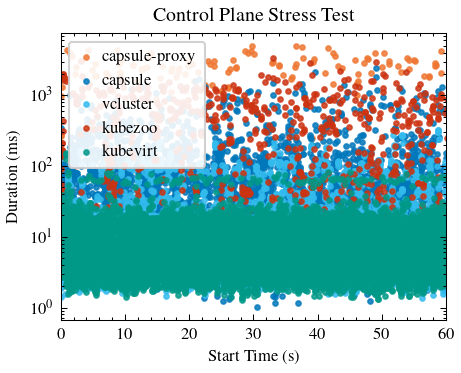

In [13]:
# plot scatter

data = []
system_to_plot = "control_plane"
for exp_name, systems in experiments.items():
        for system_name, metrics in systems.items():
                if system_name != system_to_plot:
                    continue
                baseline_metrics = metrics["baseline"]  
                unbalanced_metrics = metrics["stress_test"]
                # Extract raw data for tenant 1 from the stress test
                t1_data = unbalanced_metrics.t1_df
                # Extract start time and duration for tenant 1
                start_times = t1_data['start_time'] - t1_data['start_time'].min()  # Normalize to start at 0
                durations = t1_data['duration_ms']
                # Append to data list with label
                data.append((exp_name, start_times, durations))



fig, ax = plot_for_paper(dpi=150)
plot_scatter(data, ax, title='Control Plane Stress Test', xlabel='Start Time (s)', ylabel='Duration (ms)', filename='control_plane_stresstest_scatter')

Loading data from all solutions for regular tenant comparison...
Processing stress portion for capsule with 3267 data points...
Processing stress portion for capsule-proxy with 129 data points...
Processing stress portion for kubezoo with 673 data points...
Processing stress portion for vcluster with 9928 data points...
Processing stress portion for kubevirt with 10338 data points...


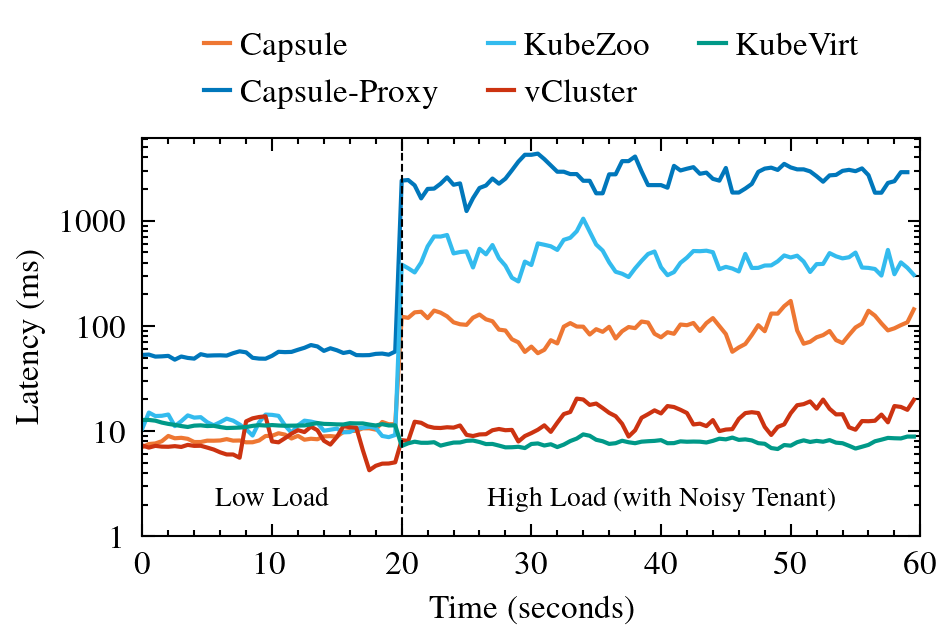

In [14]:
plot_latency_over_time(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True, max_duration=60)

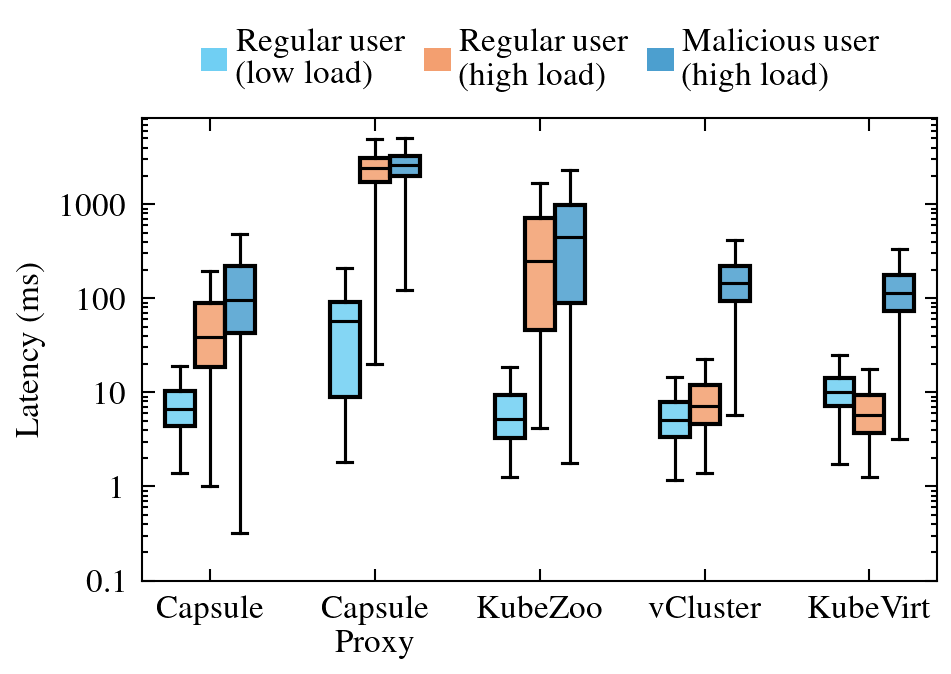


COMPARATIVE LATENCY ANALYSIS

CAPSULE-PROXY:
  Baseline:
    Requests: 2,714
    Mean: 55.2ms
    Median: 56.7ms
    P95: 103.4ms
    P99: 184.5ms
    Std Dev: 42.7ms
  Regular Tenant:
    Requests: 136
    Mean: 2370.6ms
    Median: 2406.6ms
    P95: 4297.5ms
    P99: 4867.1ms
    Std Dev: 1124.1ms
  Malicious Tenant:
    Requests: 12,274
    Mean: 2626.4ms
    Median: 2597.3ms
    P95: 4497.5ms
    P99: 5397.8ms
    Std Dev: 1050.3ms

CAPSULE:
  Baseline:
    Requests: 5,200
    Mean: 9.2ms
    Median: 6.7ms
    P95: 20.2ms
    P99: 88.4ms
    Std Dev: 11.2ms
  Regular Tenant:
    Requests: 3,280
    Mean: 91.5ms
    Median: 39.2ms
    P95: 341.8ms
    P99: 944.3ms
    Std Dev: 173.1ms
  Malicious Tenant:
    Requests: 146,218
    Mean: 199.0ms
    Median: 96.7ms
    P95: 766.5ms
    P99: 1389.1ms
    Std Dev: 280.9ms

VCLUSTER:
  Baseline:
    Requests: 5,084
    Mean: 8.4ms
    Median: 5.0ms
    P95: 16.3ms
    P99: 97.7ms
    Std Dev: 16.3ms
  Regular Tenant:
    Requests: 9,946


In [19]:
plot_latency_boxplot(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)

# plot the same but only for create operations (filtering the t1_df and t2_df to only include create operations)
# experiments_filtered = {}
# for solution, systems in experiments.items():
#     experiments_filtered[solution] = {}
#     for system_name, metrics in systems.items():
#         baseline_metrics = metrics["baseline"]  
#         unbalanced_metrics = metrics["stress_test"]
#         # Filter to only include create operations (we have a operation column with the format <op>-<resource>-<otherinfo>, so we can filter by the first part of the label)
#         baseline_filtered_df = baseline_metrics.raw_df[baseline_metrics.raw_df['operation'].str.startswith('create')]
#         stress_filtered_df = unbalanced_metrics.raw_df[unbalanced_metrics.raw_df['operation'].str.startswith('create')]
#         new_baseline_metrics = preprocessing.ExperimentData(baseline_filtered_df)
#         new_stress_metrics = preprocessing.ExperimentData(stress_filtered_df, new_baseline_metrics.as_baseline_metadata())
#         experiments_filtered[solution][system_name] = {
#             "baseline": new_baseline_metrics,
#             "stress_test": new_stress_metrics
#         }

# plot_comparative_latency_distribution(experiments_filtered, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)

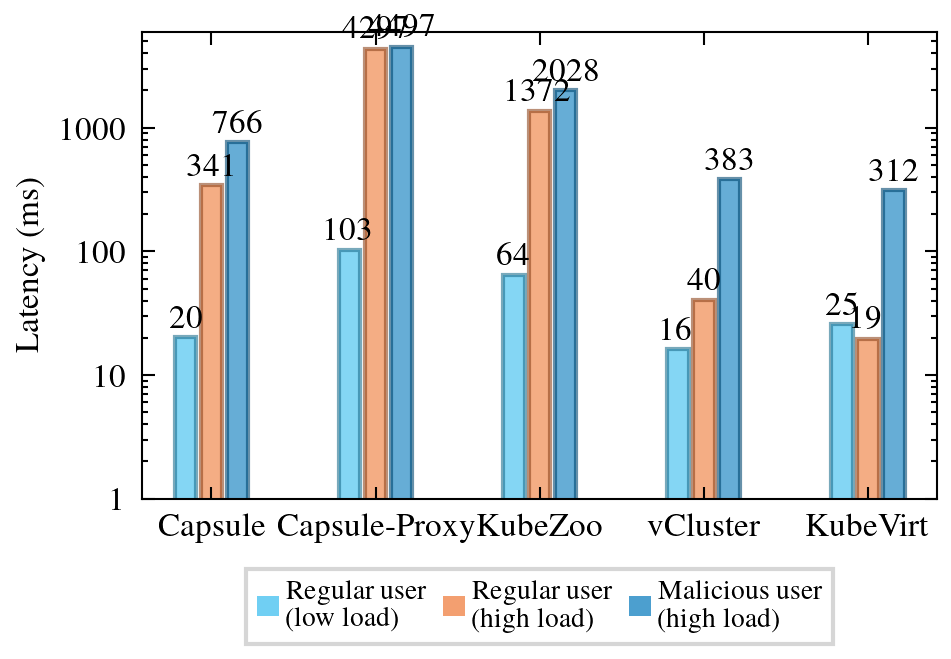


COMPARATIVE LATENCY ANALYSIS

CAPSULE-PROXY:
  Baseline:
    Requests: 2,714
    Mean: 55.2ms
    Median: 56.7ms
    P95: 103.4ms
    P99: 184.5ms
    Std Dev: 42.7ms
  Regular Tenant:
    Requests: 136
    Mean: 2370.6ms
    Median: 2406.6ms
    P95: 4297.5ms
    P99: 4867.1ms
    Std Dev: 1124.1ms
  Malicious Tenant:
    Requests: 12,274
    Mean: 2626.4ms
    Median: 2597.3ms
    P95: 4497.5ms
    P99: 5397.8ms
    Std Dev: 1050.3ms

CAPSULE:
  Baseline:
    Requests: 5,200
    Mean: 9.2ms
    Median: 6.7ms
    P95: 20.2ms
    P99: 88.4ms
    Std Dev: 11.2ms
  Regular Tenant:
    Requests: 3,280
    Mean: 91.5ms
    Median: 39.2ms
    P95: 341.8ms
    P99: 944.3ms
    Std Dev: 173.1ms
  Malicious Tenant:
    Requests: 146,218
    Mean: 199.0ms
    Median: 96.7ms
    P95: 766.5ms
    P99: 1389.1ms
    Std Dev: 280.9ms

VCLUSTER:
  Baseline:
    Requests: 5,084
    Mean: 8.4ms
    Median: 5.0ms
    P95: 16.3ms
    P99: 97.7ms
    Std Dev: 16.3ms
  Regular Tenant:
    Requests: 9,946


In [16]:
plot_comparative_latency_distribution_p95(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)

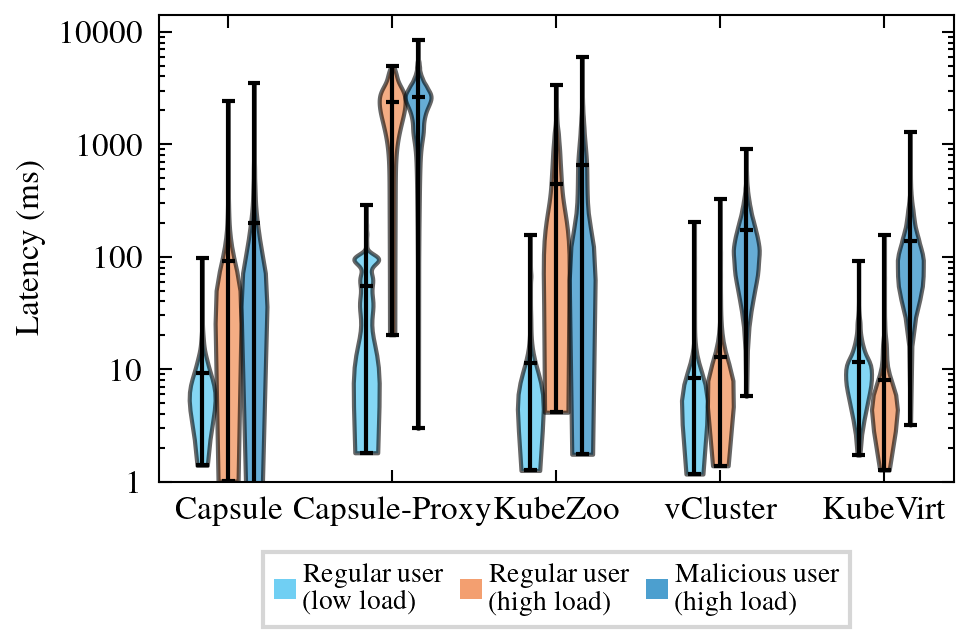


COMPARATIVE LATENCY ANALYSIS

CAPSULE-PROXY:
  Baseline:
    Requests: 2,714
    Mean: 55.2ms
    Median: 56.7ms
    P95: 103.4ms
    P99: 184.5ms
    Std Dev: 42.7ms
  Regular Tenant:
    Requests: 136
    Mean: 2370.6ms
    Median: 2406.6ms
    P95: 4297.5ms
    P99: 4867.1ms
    Std Dev: 1124.1ms
  Malicious Tenant:
    Requests: 12,274
    Mean: 2626.4ms
    Median: 2597.3ms
    P95: 4497.5ms
    P99: 5397.8ms
    Std Dev: 1050.3ms

CAPSULE:
  Baseline:
    Requests: 5,200
    Mean: 9.2ms
    Median: 6.7ms
    P95: 20.2ms
    P99: 88.4ms
    Std Dev: 11.2ms
  Regular Tenant:
    Requests: 3,280
    Mean: 91.5ms
    Median: 39.2ms
    P95: 341.8ms
    P99: 944.3ms
    Std Dev: 173.1ms
  Malicious Tenant:
    Requests: 146,218
    Mean: 199.0ms
    Median: 96.7ms
    P95: 766.5ms
    P99: 1389.1ms
    Std Dev: 280.9ms

VCLUSTER:
  Baseline:
    Requests: 5,084
    Mean: 8.4ms
    Median: 5.0ms
    P95: 16.3ms
    P99: 97.7ms
    Std Dev: 16.3ms
  Regular Tenant:
    Requests: 9,946


In [17]:
plot_comparative_latency_distribution_violin(experiments, system="control_plane", save_plots=True, out_dir="./", single_column_size=True)